# **ESERCIZIO 1.1**

**OBIETTIVI**

L'obietttivo di questo pirmo esercizio è stimare, tramite simulazione Monte Carlo e usando il metodo del data blocking
- $\langle r \rangle = \int_0^1 r dr = 1/2$,
- $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$,
- $\chi^2 = \sum_{i=1}^k \frac{\left( n_i - n/k \right)^2}{n/k}, $ k=numero di sottointervalli in cui viene diviso [0,1)

con le rispettive incertezze, utilizzando un grande numero di lanci ($>10^4$) in funzione del numero di blocchi.

In particolare, ho utilizzato 100 blocchi da 100 lanci ciascuno, per un totale di 10 000 lanci.

**IL METODO A BLOCCHI**

Per questo esercizio ho dovuto implementare il metodo del data blocking, che serve per stimare l'incertezza statistica di una grandezza simulata con il metodo Monte Carlo. Il vantaggio di usare questo metodo è che l'incertezza statistica della media viene stimata in modo più affidabile, dal momento che il metodo a blocchi permette di ridurre la correlazione interna ai dati: infatti, se calcolassi l'errore come se tutti i dati fossero indipendenti, otterrei un'incertezza minore di quella effettiva, sottostimandone così il valore.

In questo esercizio in realtà non abbiamo una vera e propria correlazione tra i dati; tuttavia, sappiamo che il generatore di numeri in realtà non genera i valori in modo del tutto casuale, ma si basa su un algoritmo che produce numeri pseudo-casuali (anche se questa correlazione è tipicamente molto piccola per buoni generatori, come quello che usiamo). Il metodo a blocchi viene comunque utilizzato perché costituisce la procedura standard per stimare l'incertezza statistica nelle simulazioni Monte Carlo.

Nel dettaglio, il metodo a blocchi consiste nel dividere gli M passi totali (simualti con Monte Carlo) in N blocchi da M/N lanci ciascuno, e per ogni blocco calcolare la media della grandezza. Se il blocco ha una dimensione (overo il numero di lanci per blocco) maggiore dell'eventuale tempo di correlazione, allora le medie di ciascun blocco diventano quantità indipendenti tra loro: per questo motivo, trattando le medie come variabili indipendenti, riesco a stimare in modo affidabile l'errore statistico.

Dunque, per ogni blocco i:
- Calcolo il valor medio della grandezza che mi interessa usando solo i lanci all'interno di quel blocco specifico: $A_i$
- Calcolo il quadrato: $A_i^2$
- Accumulo i risultati sommando progressivamente i valori $A_i$ e $A_i^2$ ottenuti dai blocchi precedenti per ottenere le medie cumulative: $$ \langle A^2 \rangle \simeq \frac{1}{n} \sum_{i=1}^n A^2_i \quad \quad \langle A\rangle^2 \simeq \left( \frac{1}{n} \sum_{i=1}^n A_i \right)^2 $$
- Calcolo  $\sigma^2_A = \langle A^2 \rangle -\langle A\rangle^2 $
- Stimo l'incertezza statistica:$$ \text{err(n)} = \sqrt{\frac{1}{n-1} \left[ \frac{1}{n} \sum_{i=1}^n A^2_i - \left( \frac{1}{n} \sum_{i=1}^n A_i \right)^2 \right]} $$


**IMPLEMENTAZIONE**

- CICLO INTERNO (sul numero di lanci per blocco): in questo ciclo devo calcolare il valor medio della grandezza che sto analizzando: uso il generatore per estrarre $u\in[0,1)$, dopodichè uilizzo $u$ per stimare la grandezza che mi interessa (usando le formule riportate sopra)
- CICLO ESTERNO (sul numero di blocchi): in questo ciclo implemento il data blocking: prima di tutto devo azzerare il contatore $somma$, che accumula i valori della grandezza all'interno del ciclo interno. Dopodichè accumulo i contatore $medie$ e $medie2$, che contengono rispettivamente il valor medio e il valor medio al quadrato. Procedo calcolando, sia per $medie$ sia per $medie2$, la somma progressiva, ovvero divido $medie$ e $medie2$ per il numero del blocco corrente. Infine, calcolo l'errore progressivo. In particolare, per il primo blocco non posso calcolare l'incertezza (che sarà quindi 0), in quanto matematicamente sia il numeratore sia il denominatore si annullano, e statisticamente non ha senso calcolare la fluttuazione dal momento che ho un solo dato a disposizione.

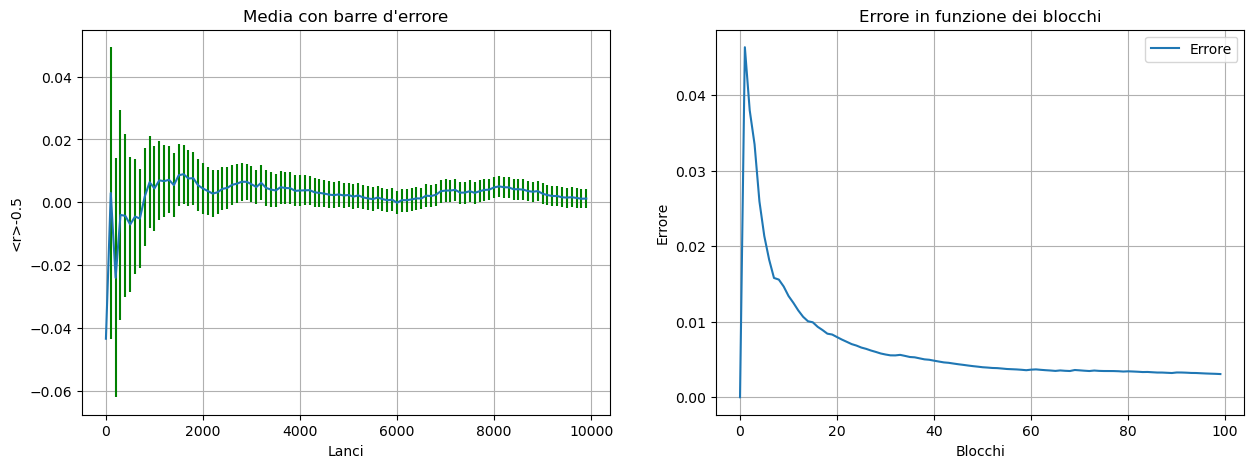

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2


lanci=10000
blocchi=100
n=int(lanci/blocchi)

#genero array di interi da 0 a 99
x=np.arange(blocchi)

#carico i file da graficare
media=np.loadtxt("01.1/Media.dat")
varianza=np.loadtxt("01.1/Errore.dat")

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
x=(x*n)
plt.errorbar(x, media-0.5, yerr=varianza, ecolor='green')
plt.xlabel('Lanci')
plt.ylabel('<r>-0.5')
plt.title("Media con barre d'errore")
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(varianza,label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi")
plt.legend()
plt.grid(True)
plt.show()


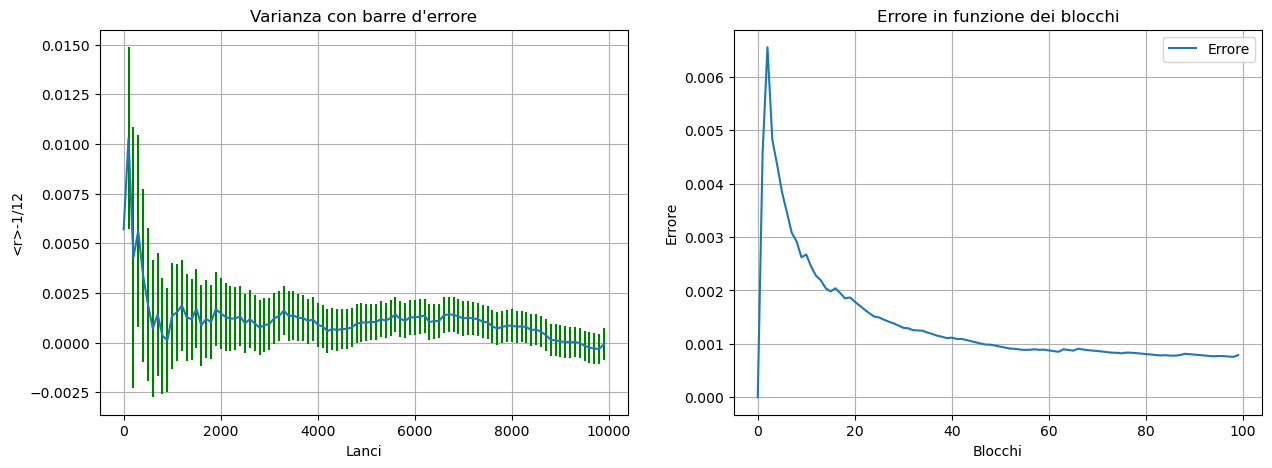

In [2]:
media=np.loadtxt("01.1/Media_var.dat")
varianza=np.loadtxt("01.1/Errore_var.dat")

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)

plt.errorbar(x, media-1/12, yerr=varianza, ecolor='green')
plt.xlabel('Lanci')
plt.ylabel('<r>-1/12')
plt.title("Varianza con barre d'errore")
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(varianza,label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi")
plt.legend()
plt.grid(True)
plt.show()

**COMMENTO AI RISULTATI**

Entrambi i grafici mostrano che, all'aumentare del numero di lanci, i valori di $\langle r\rangle$-valore atteso e di $\sigma^2$-valore atteso si stabilizano in modo più o meno preciso attorno allo zero, confermando che in entrambi i casi l'utilizzo del metodo di MC è stato efficiente per stimare il valore delle grandezze richieste, che convergono appunto al valore atteso. Inoltre, la convergenza mostra anche che la scelta di dividere i passi totali in 100 blocchi da 100 lanci ciascuno si è rivelata efficace.

In entrambi i casi l'errore segue l'andamento atteso: ci aspettiamo infatti che diminuisca come $\frac{1}{\sqrt{N}}$ all'aumentare del numero di lanci, e così avviene in entrambi i grafici. Questo è coerente con il Teorema del Limite Centrale, che prevede che l'errore scali come $\frac{1}{\sqrt{N}}$.

Osservando i grafici notiamo anche che per i primi lanci i dati oscillano prima di stabilizarsi attorno allo zero: questo è dovuto al fatto che nei primi blocchi abbiamo ancora una statistica insufficiente di dati per poter stimare correttamente il valore delle grandezze richieste, ma man mano che aumentano i lanci (e quindi la statistica) il valore tende a stabilizzarsi a zero, entro le barre d'errore.

**CHI QUADRO**

Nell'esericizo 1.1 ho implementato anche il test del chi quadro di Pearson, al fine di verificare se i numeri generati dal generatore casuale utilizzato siano effettivamente distribuiti in modo uniforme nell'intervallo [0,1). In particolare, in statistica non è possibile dimostrare in modo assoluto che un insieme di dati provenga da una certa distribuzione; si può però testare la compatibilità dei dati con tale ipotesi. Nel caso specifico, si utilizza il test del chi quadro di Pearson per valutare quanto le frequenze osservate si discostino da quelle attese sotto l’ipotesi di distribuzione uniforme.

In particolare, il test del chi quadro misura la discrepanza tra i dati simulati ($O_i$) e quelli teorici ($E_i$), secondo la formula:
$$\chi^2 = \sum_{i} \frac{\left( O_i - E_i \right)^2}{E_i}$$

Il numeraotre rappresenta lo scarto tra la "frequenza" che mi aspetto per numeri estratti da una distribuzione uniforme e quella teorica, ed è elevato al quadrato: il quadrato serve a penalizzare allo stesso modo deviazioni positive e negative, rendendo la misura indipendente dal segno dello scostamento, e a dare più peso agli scostamenti più grandi. Questo scarto viene confrontato con il denominatore, che è la varianza attesa della distribuzione relativa e che in questo caso coincide con $E_i$, ovvero con il valore atteso di lanci nell'intervallo i-esimo. Questo è dovuto al fatto che il processo che stiamo analizzando è ben descritto dalla distribuzione binomiale, che calcola la probabilità di ottenere $k$ successi in un numero $n$ di prove indipendenti tra loro, con $p$ probabilità di successo in una singola prova. Infatti, dividendo l'intervallo in M bin, ciascuna estrazione ha probabilità 1/M di finire nel bin i-esimo. In particolare, nella distribuzione binomiale il valor medio è $\langle X \rangle = np$ e la varianza $\sigma^2 = np (1-p)$. Di conseguenza, per valori di $p$ piccoli (in questo caso p=1/M), $\sigma^2 = np (1-p)\sim np = \langle X \rangle $. Questo spiega il denominatore del $\chi^2$.

**IMPLEMENTAZIONE**

Nel codice che ho implementato eseguo per un numero $ripe=100$ di volte il test del chi quadro sul generatore di numeri casuali. Per questo motivo, ho fatto un ciclo esterno sul numero di ripetizioni del test. Ciascun test consiste nel generare $n_\text{lanci}$ numeri uniformemente distribuiti in [0,1) e incrementare di un'unità il contatore associato al bin in cui cade il numero estratto. In particolare, ho diviso l'intervallo [0,1) in M=100 intervalli uguali, ciascuno di ampiezza $\frac{1}{100}$: per capire in che bin cade il numero estratto mi basta semplicemente prendere la parte intera del prodotto tra il valore estratto (tra 0 e 1) e il numero di intervalli (è come se avessi estratto il numero tra 0 e 100, il che mi dà direttamente il bin corrispondente). Infine, calcolo il chi quadro con la formula riportata sopra.

Dal momento che i dati vengono estratti da una distribuzione uniforme, mi aspetto che, dopo $n_\text{lanci}$, il numero di eventi osservati in ciascun sottointervallo sia pari a $\frac{n_\text{lanci}}{M}$. Dunque, in questo caso $\chi^2 = \sum_{i=1}^M \frac{\left( n_i - n/M \right)^2}{n/M}$. Ci aspettiamo in media che $(n_i - n/M)^2 \simeq n/M$, e per questo motivo ogni termine della sommatoria ha valore medio circa 1, e quindi la somma degli M termini porta ad avere $\chi^2\sim M$.

Avendo utilizzato M=100 per la mia simulazione, mi aspetto quindi che $\chi^2\sim 100$. Un valore più grande di $\chi^2$ indica una scarsa compatibilità con l’ipotesi di distribuzione uniforme.

Valor medio:  99.91359999999999
Deviazione standard:  13.882236960951214


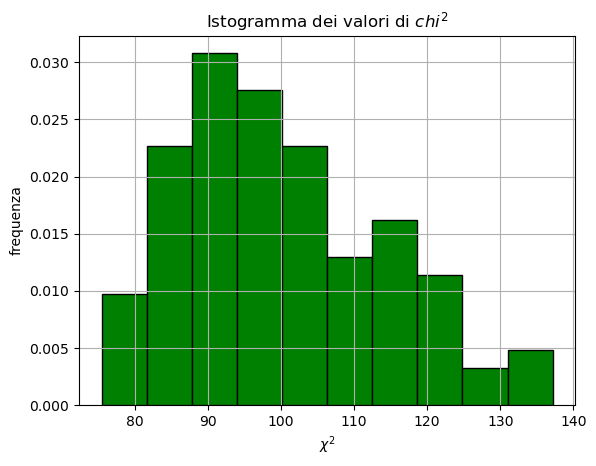

In [3]:
data=np.loadtxt("01.1/X.dat")

#stampo istogramma
plt.hist(data, bins=10, density=True, color='green', edgecolor='black')

#ricavo valor medio + stddev dai dati
media=np.mean(data)
stddev=np.std(data)

print("Valor medio: ", media)
print("Deviazione standard: ", stddev)

plt.xlabel(r'$\chi^2$')
plt.ylabel('frequenza')
plt.title('Istogramma dei valori di $chi^2$')
plt.grid(True)
plt.show()

Eseguo un confronto tra l'istogramma e la vera distribuzione di probabilità con 99 gradi di libertà, per verificare che i valori ottenuti dalla simulazione siano compatibili con l'andamento teorico.

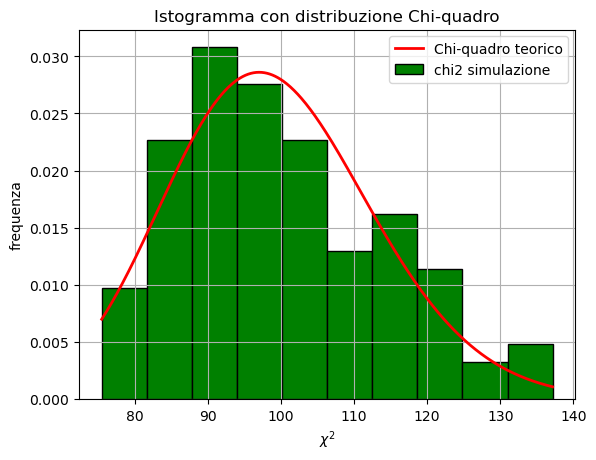

In [4]:
gdl=99

x=np.linspace(min(data), max(data), 500)
y=chi2.pdf(x, gdl) #eseguo il fit per il chi2

plt.plot(x, y, 'r-', lw=2, label='Chi-quadro teorico')
plt.hist(data, bins=10, density=True, color='green', edgecolor='black', label="chi2 simulazione")

plt.xlabel('$\chi^2$')
plt.ylabel('frequenza')
plt.title('Istogramma con distribuzione Chi-quadro')
plt.legend()
plt.grid()
plt.show()


**COMMENTO AI RISULTATI**

Avendo ottenuto un valor medio compatibile, entro l'incertezza associata, con il valore atteso per il $\chi^2$ (100), concludiamo che effettivamente l'ipotesi per cui i numeri sono estratti da una distribuzione uniforme in $[0,1)$ non può essere rifiutata.

Inoltre, dal confronto con la distribuzione teorica con 99 gradi di libertà l'istogramma riproduce piuttosto fedelmente l'andamento della distribuzione reale, confermando anche visivamente la compatibilità.

Dunque, questo ci permette di affermare che il generatore di numeri pseudo-casuali produce sequenze compatibili con una distribuzione uniforme in [0,1).

# **ESERCIZIO 1.2**

**OBIETTIVI**

In questo esercizio devo estendere il generatore anche alle distribuzioni esponenziale e lorentziana, per verificare il Teorema del Limite Centrale. In particolare, per campionare queste due distribuzioni devo invertire le rispettive funzioni cumulative. Infatti, il generatore sa estrarre solo numeri casuali distribuiti uniformemente in [0,1], e per questo devo "ricostruire" tutte le altre distribuzioni basandomi su quella uniforme.

Per farlo, considero una distribuzione di probabilità $p(x)$ di una variabile continua $X$. Definisco la funzione cumulativa $F(x)=P(X\le x)$, ovvero come la probabilità che la mia variabile $X$ assuma un valore minore o uguale a un dato valore $x$. Di consguenza, essendo una probabilità, la funzione cumulativa assumerà valori compresi tra [0,1], e allora: $x=F^{-1}(u)$. Pertanto, posso ottenere la distribuzione che desidero (secondo cui $X$ è distribuito) invertendo la funzione cumulativa.

In particolare, per ciasuna delle tre distribuzioni (dado standard, esponenziale, lorentziana) devo realizzare quattro istogrammi, ottenuti usando 10 000 realizzazioni della variabile:
$$S_N = \frac{1}{N}\sum_{i=1}^N x_i$$
per i diversi valori di $N=1,2,10,100$.

**TEOREMA DEL LIMITE CENTRALE**

Siano $X_1, X_2, \dots, X_N$ variabili casuali idipendenti e identicamente distribuite con $\langle X_i \rangle = \mu$ e $\sigma^2 < \infty$
Definita la media campionaria $S_N = \frac{1}{N} \sum_{i=1}^{N} X_i$, allora per $N \to \infty \text{  si ha che  } Z_N = \frac{S_N - \mu}{\sigma / \sqrt{N}} \xrightarrow{} \mathcal{N}(0, 1)$

**IMPLEMENTAZIONE**

Le funzioni cumulative delle distribuzioni esponenziale e lorentziana sono le seguenti:

- ESPONENZIALE: $F(x)=1-e^{-\lambda x}, \quad x \ge 0$
- LORENTZIANA: $F(x)=\frac{1}{\pi}\arctan\!\left(\frac{x-x_0}{\gamma}\right)+\frac{1}{2}, \quad x \in (-\infty, +\infty)$

Ho quindi aggiornato il generatore casuale aggiungendo le distribuzioni:

- ESPONENZIALE: $\frac{-1}{\lambda}\log(1-n)$, dove $n$ è un numero estratto uniformemente $\in[0,1)$
- LORENTZIANA: $x_0+\gamma\tan(\pi(n-0.5))$, con $x_0$ e $\gamma$ rispettivamente centro e larghezza della distribuzione.

tramite il metodo dell'inversione della cumulativa.

Nel $main()$ ho invece implementato la simulazione:

- CICLO ESTERNO su L=10000 realizzazioni:
- CICLO INTERMEDIO su $i=0,1,2,3$: dal momento che devo fare 4 simulazioni diverse (in base a $N$), all'inizio di questo ciclo devo azzerare i contatori della somma di tutte e tre le distribuzioni; al termine della simulazione stampo i valori della media (ottenuti come $somma/N$ su un file
- CICLO INTERNO sui diversi valori di N: ripeto la simulazione tante volte quante il numero di $N$ corrispondente (1,2,10,100)

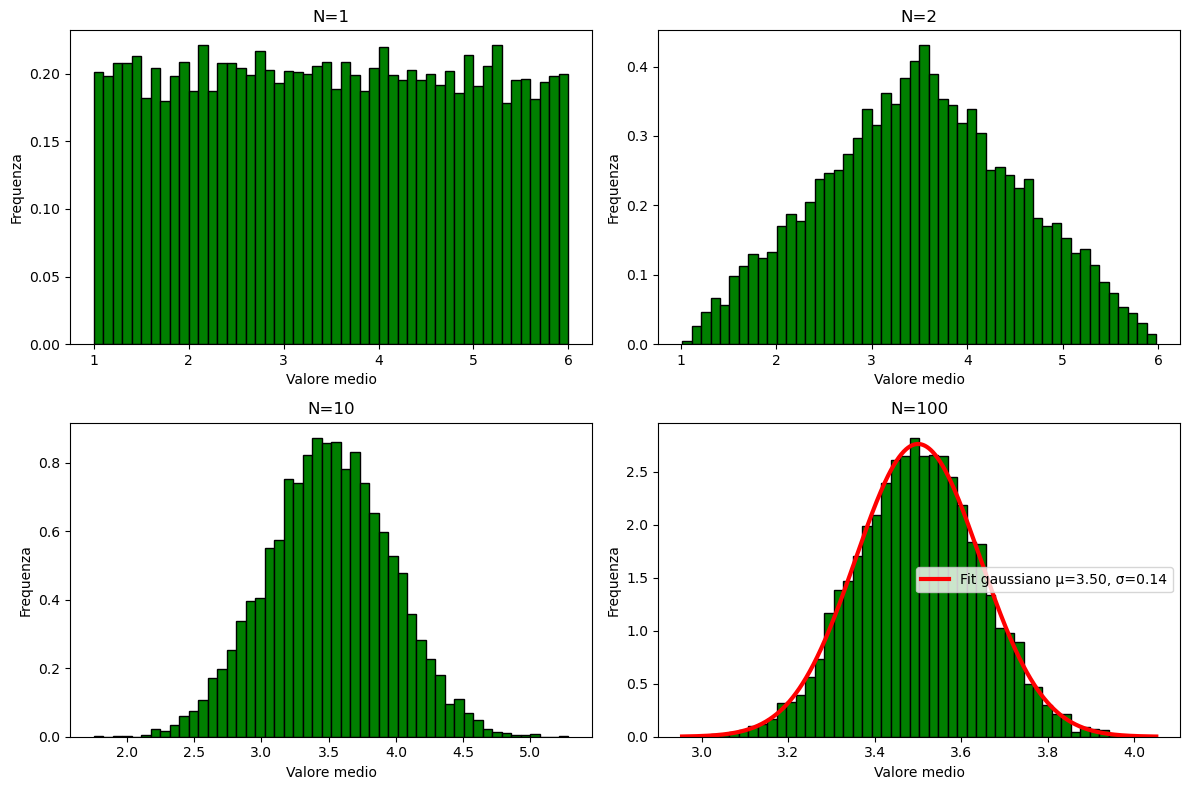

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#carico dati
dadi=np.loadtxt("01.2/Dadi.dat")

#seleziono le singole colonne
col1 = dadi[:, 0]  # N=1
col2 = dadi[:, 1]  # N=2
col3 = dadi[:, 2]  # N=10
col4 = dadi[:, 3]  # N=100

plt.figure(figsize=(12,8))  # grandezza della figura

plt.subplot(2,2,1) #primo grafico
plt.hist(col1, bins=50, density=True, color='green', edgecolor='black')
plt.title("N=1")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")

plt.subplot(2,2,2)  #secondo grafico
plt.hist(col2, bins=50, density=True, color='green', edgecolor='black')
plt.title("N=2")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")

plt.subplot(2,2,3)  #terzo grafico
plt.hist(col3, bins=50, density=True, color='green', edgecolor='black')
plt.title("N=10")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")

plt.subplot(2,2,4)  #quarto grafico
plt.hist(col4, bins=50, density=True, color='green', edgecolor='black')
plt.title("N=100")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")

#confronto con gaussiana teorica (usando media e sigma dai miei dati)
media=col4.mean()
sigma=col4.std()

#imposto limiti del mio asse x
max=col4.max()
min=col4.min()
x=np.linspace(min,max,1000)

#costruisco distribuzione gaussiana
gauss=stats.norm.pdf(x,loc=media,scale=sigma) 
plt.plot(x, gauss, 'r-', lw=3, label=f'Fit gaussiano μ={media:.2f}, σ={sigma:.2f}') #.2f=stampata con 2 decimali
plt.legend()
plt.tight_layout()  # sistema i grafici in modo che non si sovrappongano
plt.show()

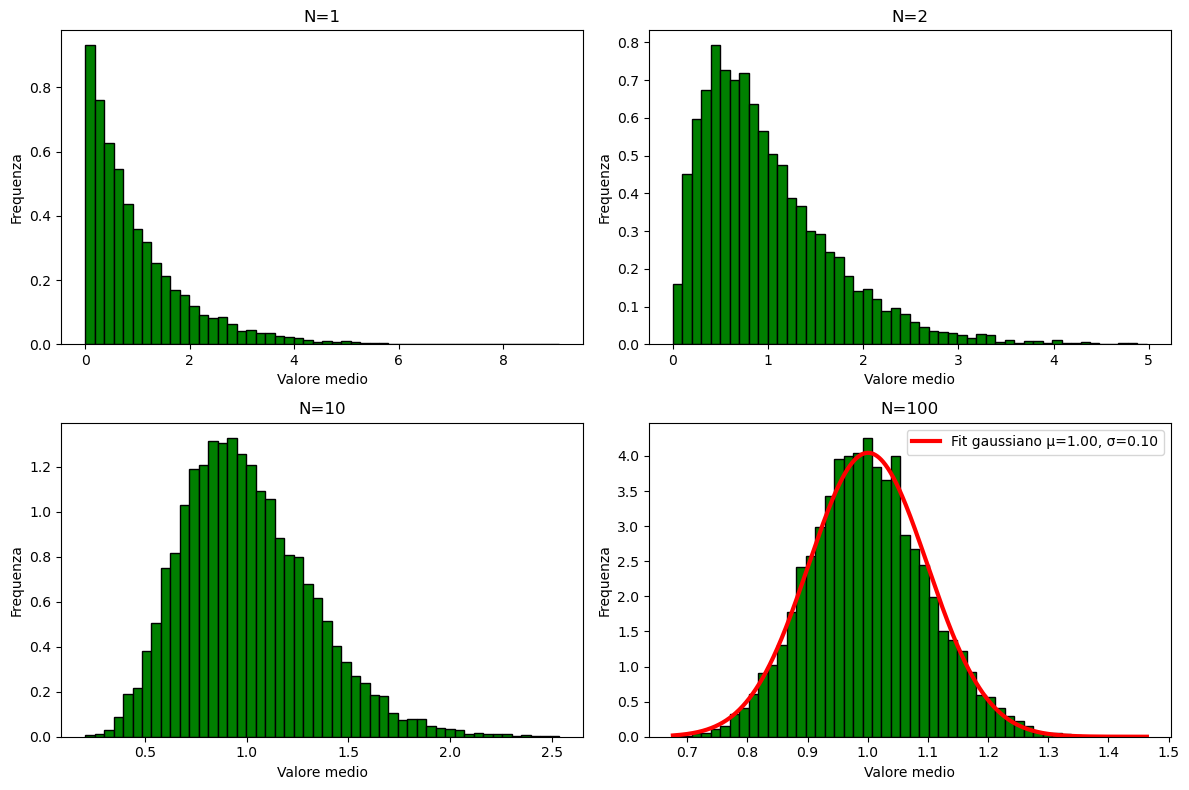

In [4]:
exp=np.loadtxt("01.2/Esponenziale.dat")

col1 = exp[:, 0]  # N=1
col2 = exp[:, 1]  # N=2
col3 = exp[:, 2]  # N=10
col4 = exp[:, 3]  # N=100

plt.figure(figsize=(12,8))  # grandezza della figura

plt.subplot(2,2,1)  # primo grafico
plt.hist(col1, bins=50, density=True, color='green', edgecolor='black')
plt.title("N=1")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")

plt.subplot(2,2,2)  # secondo grafico
plt.hist(col2, bins=50,density=True, color='green', edgecolor='black')
plt.title("N=2")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")

plt.subplot(2,2,3)  # terzo grafico
plt.hist(col3, bins=50, density=True, color='green', edgecolor='black')
plt.title("N=10")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")

plt.subplot(2,2,4)  # quarto grafico
plt.hist(col4, bins=50, density=True, color='green', edgecolor='black')
plt.title("N=100")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")

media=col4.mean()
sigma=col4.std()
max=col4.max()
min=col4.min()
x=np.linspace(min,max,1000) 
gauss=stats.norm.pdf(x,loc=media,scale=sigma) #distribuzione gaussiana
plt.plot(x, gauss, 'r-', lw=3, label=f'Fit gaussiano μ={media:.2f}, σ={sigma:.2f}')
plt.legend()
plt.tight_layout()  #sistema i grafici in modo che non si sovrappongano
plt.show()

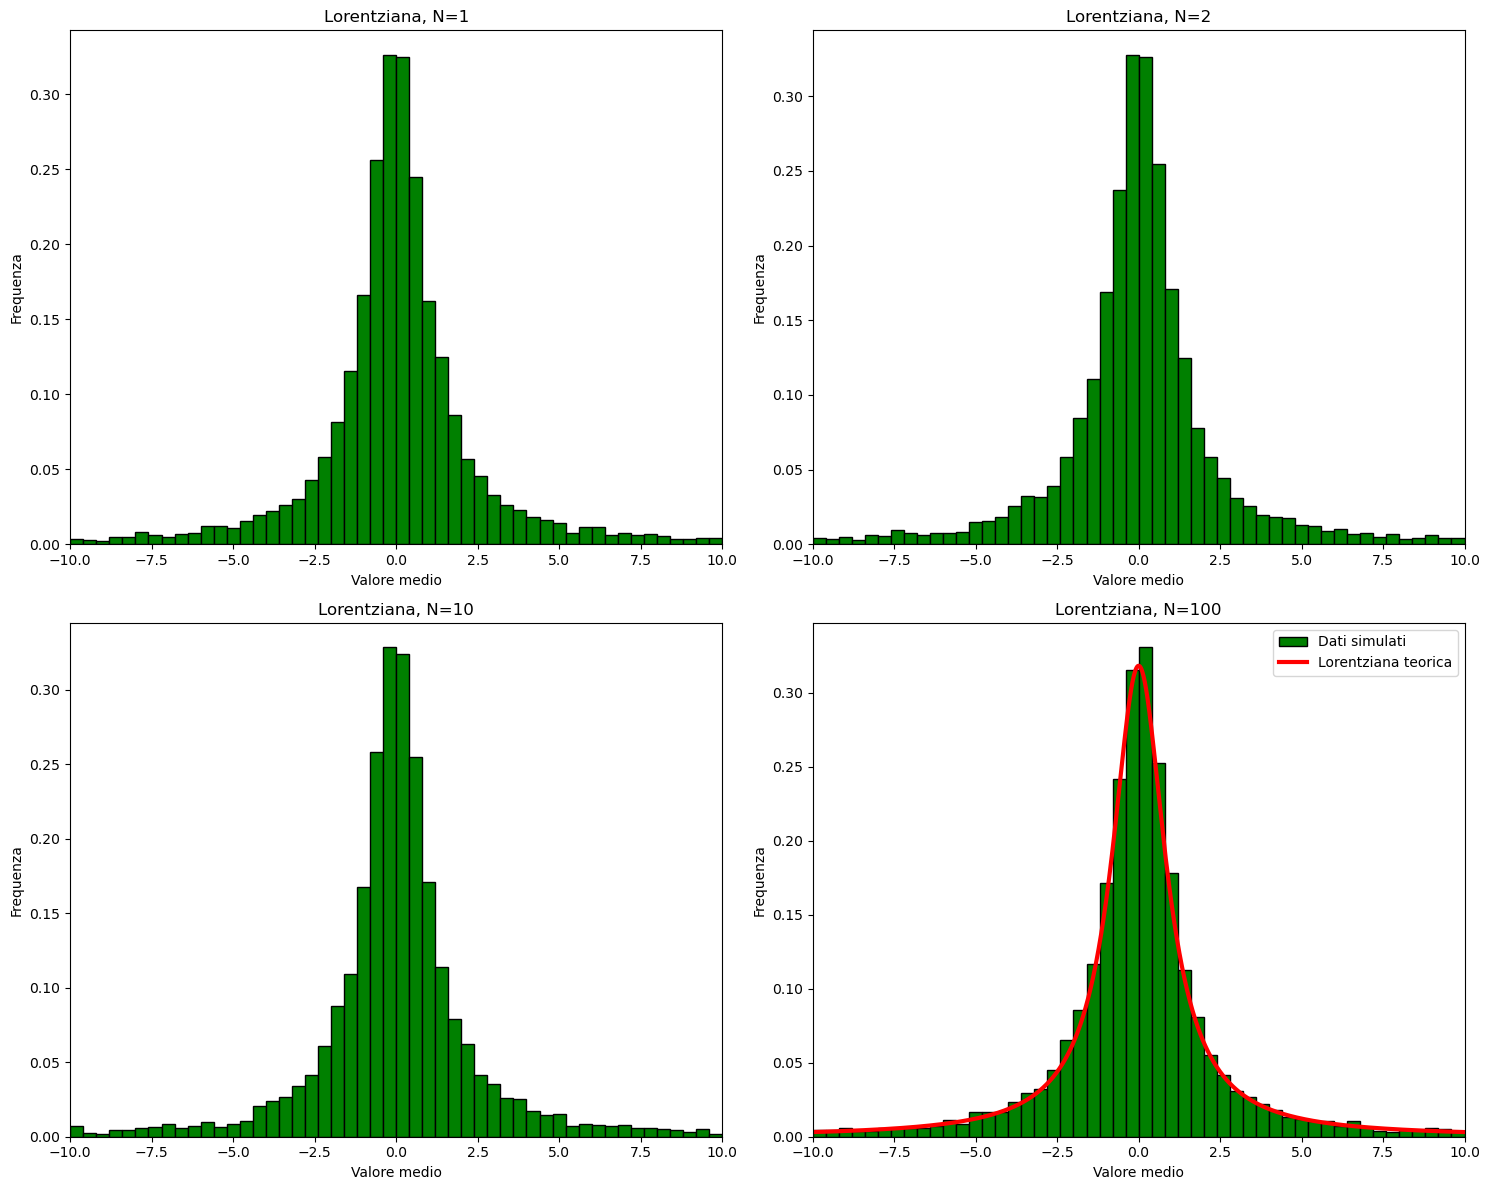

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#Caricamento dati
lor = np.loadtxt("01.2/Lorentziana.dat")

col1 = lor[:, 0]  #N=1
col2 = lor[:, 1]  #N=2
col3 = lor[:, 2]  #N=10
col4 = lor[:, 3]  #N=100

#Parametri teorici della consegna
mu=0.0
gamma=1.0

#definisco un intervallo sensato per la visualizzazione (da -10 a 10) perché la Lorentziana ha "long tails" che manderebbero la scala a infinito
limiti=(-10, 10)

plt.figure(figsize=(15,12))

#Grafico N=1
plt.subplot(2,2,1)
plt.hist(col1, bins=50, range=limiti, density=True, color='green', edgecolor='black')
plt.title("Lorentziana, N=1")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")
plt.xlim(limiti)

#Grafico N=2
plt.subplot(2,2,2)
plt.hist(col2, bins=50, range=limiti, density=True, color='green', edgecolor='black')
plt.title("Lorentziana, N=2")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")
plt.xlim(limiti)

#Grafico N=10
plt.subplot(2,2,3)
plt.hist(col3, bins=50, range=limiti, density=True, color='green', edgecolor='black')
plt.title("Lorentziana, N=10")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")
plt.xlim(limiti)

#Grafico N=100 con curva teorica
plt.subplot(2,2,4)
plt.hist(col4, bins=50, range=limiti, density=True, color='green', edgecolor='black', label='Dati simulati')

#Calcolo curva teorica di cauchy direttamente nell'asse x limitato
x_teorico=np.linspace(limiti[0], limiti[1], 1000)
# Formula analitica: (1/pi) * (Gamma / ((x-mu)^2 + Gamma^2))
y_teorico=(1.0/np.pi)*(gamma/((x_teorico-mu)**2+gamma**2))

plt.plot(x_teorico, y_teorico, color='red', lw=3, label='Lorentziana teorica')
plt.title("Lorentziana, N=100")
plt.xlabel("Valore medio")
plt.ylabel("Frequenza")
plt.xlim(limiti)
plt.legend()

plt.tight_layout()
plt.show()

**COMMENTO AI RISULTATI**

Per il dado standard e per la distribuzione esponenziale ho fatto un fit gaussiano perchè entrambe queste distribuzioni hanno varianza finita; al contrario, per la distribuzione di Cauchy-Lorentz ho invece fatto un fit lorentziano, dal momento che questa distribuzione non ha nè varianza finita nè media bene definita. Per il Teorema del Limite Centrale, infatti, la distribuzione della media $S_N$ tende a una gaussiana quando N è sufficientmente grande, a patto di soddisfare le ipotesi del teorema, in particolar modo quella per cui la distribuzione deve avere varianza finita. Al contrario, la Cauchy-Lorentz non soddisfa le ipotesi del TLC, e di conseguenza la media campionaria non converge a una gaussiana e la distribuzione di $S_N$ mantiene la forma lorentziana.

I risultati ottenuti mostrano quindi che, per dado standard ed esponenziale, la distribuzione della media campionaria tende a una gaussiana al crescere di N, mentre nel caso della Cauchy-Lorentz la distribuzione mantiene la sua forma lorentziana e non segue il comportamento previsto dal Teorema del Limite Centrale.

# **ESERCIZIO 1.3**

**OBIETTIVI**

L'obiettivo di questo esercizio è stimare il valore di pigreco usando il metodo dell'esperimento dell'ago di Buffon.

L'esperimento consiste nel lanciare casualmente un ago di lunghezza $L$ su un piano segnato da linee parallele poste a distanza $d$ tra loro, in modo che $d>L$. La probabilità che l'ago intersechi una delle linee è data dalla formula $P= \frac{2L}{\pi d}$. Questa relazione permette di ricavare $\pi$ sperimentalmente: se lanciamo l'ago $N_\text{thr}$ volte e osserviamo che tocca una linea $N_\text{hit}$ volte, la stima di $\pi$ sarà:

$$\pi= \frac{2L}{P d} = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d}$$
**IMPLEMENTAZIONE**

Per calcolare $\sin\theta$ in modo che l'angolo $\theta$ sia uniformemente distribuito tra [0,$\pi$/2], senza utilizzare il valore M_PI incluso nella libreria $cmath$, ho fatto in questo modo:

1. estraggo uniformemente tra 0 e 1 due coordinate $x$ e $y$
2. calcolo la loro distanza dall'origine fin quando non è <=1: in questo modo, tengo solamente i punti che si trovano all'interno del quarto di cerchio di raggio 1
3. calcolo $\sin\theta=\frac{y}{r}$, con $r=\sqrt{x^2+y^2}$

Questo metodo, in particolare il punto 2.,  mi permette di estrarre $\sin\theta$ in modo che l'angolo $\theta$ sia uniformemente distribuito tra [0;$\pi/2$]: infatti, io so che il rapporto tra l'area di $\frac{1}{4}$ di cerchio di raggio r e l'area di un quadrato di lato $r$ è $\frac{\pi r^2}{4r^2}=\frac{\pi}{4}$ e questa è la probabilità di estrarre un punto in un quarto di cerchio. In particolare, il campionamento uniforme nel quarto di disco garantisce, per simmetria rotazionale, che tutte le direzioni siano equiprobabili e quindi $\theta$ risulta uniforme in [0,$\pi$/2].

Per quanto riguarda il metodo di Buffon, l'ho implementato nel seguente modo:
- genero la posizione $pos$ dell'estremo inferiore dell'ago in [0,1), ovvero sfrutto la simmetria traslazionale del reticolo ed estraggo $pos$ solamente tra le prime due righe del reticolo (ogni posizione può infatti essere sempre ricondotta in questa regione tramite traslazione)
- se $L\sin\theta + pos >= d$, dove $d$ è la distanza tra due righe consecutive del reticolo, allora incremento il contatore che segnala l'avvenuta intersezione tra l'ago e il reticolo
- calcolo $\pi = \frac{2L}{Pd} = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d}$

In particolare, ho usato come parametri:

    int M=100000;     numero totale di lanci
    int N=100;        numero di blocchi
    int lanci=M/N;    lanci per blocco

    double L=0.7;     lunghezza dell'ago
    double d=1.0;     "passo" del reticolo

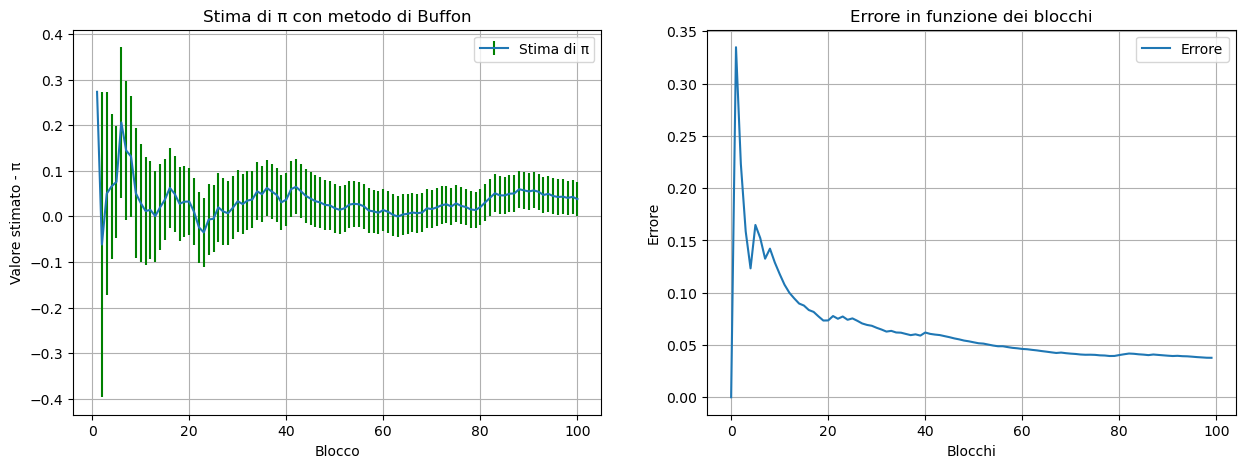

In [10]:
import matplotlib.pyplot as plt
import numpy as np

#leggo i dati
data=np.loadtxt("01.3/PI.dat")
PI=data[:,0]    # prima colonna
error=data[:,1]     # seconda colonna

# Crea l'asse x (numero di blocco)
N=100
x=data[:,2]

plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)

# Grafico con barre di errore
plt.errorbar(x, PI-np.pi, yerr=error, ecolor='green', label="Stima di π")
plt.xlabel("Blocco")
plt.ylabel("Valore stimato - π")
plt.title("Stima di π con metodo di Buffon")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(error,label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi")
plt.legend()
plt.grid(True)
plt.show()


**COMMENTO AI RISULTATI**

Osservando il grafico noto innanzitutto che, all'aumentare del numero di blocchi, la media progressiva tende a stabilizzarsi attorno al valore teorico di pigreco, confermando l'effettiva validità del metodo di Buffon per la stima di $\pi$.

In particolare, per i primi $\sim$20 blocchi l'andamento della media progressiva risulta oscillante e caratterizzato da errori relativamente ampi, segno che la statistica di eventi campionati è ancora insufficiente per fornire una stima affidabile del valore atteso. Aumentando progressivamente il numero di blocchi, osserviamo da un lato una diminuzione dell'oscillazione dei valori stimati, che convergono verso il valore atteso, e dall'altro una riduzione delle barre d'errore. Entrambe queste caratteristiche sono una conseguenza del metodo del data blocking, che permette di ridurre la varianza della stima trattando le medie di blocco come variabili indipendenti.

In particolare, la riduzione dell’errore sulla media al crescere del numero di blocchi è coerente con l’andamento previsto dal Teorema del Limite Centrale, che ci dice che l'errore ha un andamento $\sim \frac{1}{\sqrt{N}}$.